In [6]:
import kagglehub
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import time
import copy

In [7]:
# Set device to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [ ]:
# # Download dataset using kagglehub
# dataset_path = kagglehub.dataset_download("youssefmohmmed/dogs-skin-diseases-image-dataset")

# # Define paths
# train_dir = os.path.join(dataset_path, "train")
# valid_dir = os.path.join(dataset_path, "valid")
# test_dir = os.path.join(dataset_path, "test")

# print("Dataset is ready!")
# print(f"Train Data Path: {train_dir}")
# print(f"Validation Data Path: {valid_dir}")
# print(f"Test Data Path: {test_dir}")


In [8]:
"""Data Preprocessing and Loading"""

# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder("./train", data_transforms['train']),
    'valid': datasets.ImageFolder("./valid", data_transforms['valid']),
    'test': datasets.ImageFolder("./test", data_transforms['test'])
}

# Create dataloaders
batch_size = 32
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True),
    'valid': DataLoader(image_datasets['valid'], batch_size=batch_size),
    'test': DataLoader(image_datasets['test'], batch_size=batch_size)
}

# Print class labels
class_names = image_datasets['train'].classes
print("Class Labels:", class_names)
num_classes = len(class_names)

Class Labels: ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']


In [9]:
"""Model Definition and Training"""

# Load pretrained MobileNetV2 model
model_ft = models.mobilenet_v2(pretrained=True)

# Freeze all layers
for param in model_ft.parameters():
    param.requires_grad = False

# Modify the classifier
model_ft.classifier[1] = nn.Linear(model_ft.last_channel, num_classes)

# Move model to device
model_ft = model_ft.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.classifier[1].parameters(), lr=0.0001)

# Learning rate scheduler
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)
        
        # Each epoch has a training and validation phase
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode
            
            running_loss = 0.0
            running_corrects = 0
            
            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
                
                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            if phase == 'train':
                scheduler.step()
            
            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            # Save training and validation metrics for plotting
            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.cpu().numpy())
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.cpu().numpy())
            
            # Deep copy the model
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        print()
    
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')
    
    # Load best model weights
    model.load_state_dict(best_model_wts)
    
    # Plot training performance
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_accs, label="Train Accuracy")
    plt.plot(val_accs, label="Validation Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")
    
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.legend()
    plt.title("Loss Curve")
    
    plt.show()
    
    return model

d:\conda_envs\catdog\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\conda_envs\catdog\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\alei/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:13<00:00, 1.03MB/s]


Epoch 0/19
----------
train Loss: 1.6796 Acc: 0.2879
valid Loss: 1.4738 Acc: 0.4593

Epoch 1/19
----------
train Loss: 1.4379 Acc: 0.4987
valid Loss: 1.2577 Acc: 0.5953

Epoch 2/19
----------
train Loss: 1.2819 Acc: 0.5857
valid Loss: 1.1258 Acc: 0.6465

Epoch 3/19
----------
train Loss: 1.1812 Acc: 0.6152
valid Loss: 1.0354 Acc: 0.6663

Epoch 4/19
----------
train Loss: 1.1167 Acc: 0.6337
valid Loss: 0.9743 Acc: 0.6721

Epoch 5/19
----------
train Loss: 1.0596 Acc: 0.6529
valid Loss: 0.9151 Acc: 0.6953

Epoch 6/19
----------
train Loss: 1.0307 Acc: 0.6605
valid Loss: 0.8851 Acc: 0.7012

Epoch 7/19
----------
train Loss: 0.9972 Acc: 0.6668
valid Loss: 0.8815 Acc: 0.7000

Epoch 8/19
----------
train Loss: 0.9859 Acc: 0.6817
valid Loss: 0.8689 Acc: 0.7070

Epoch 9/19
----------
train Loss: 0.9833 Acc: 0.6668
valid Loss: 0.8641 Acc: 0.7070

Epoch 10/19
----------
train Loss: 0.9942 Acc: 0.6645
valid Loss: 0.8673 Acc: 0.7058

Epoch 11/19
----------
train Loss: 0.9797 Acc: 0.6744
valid Loss

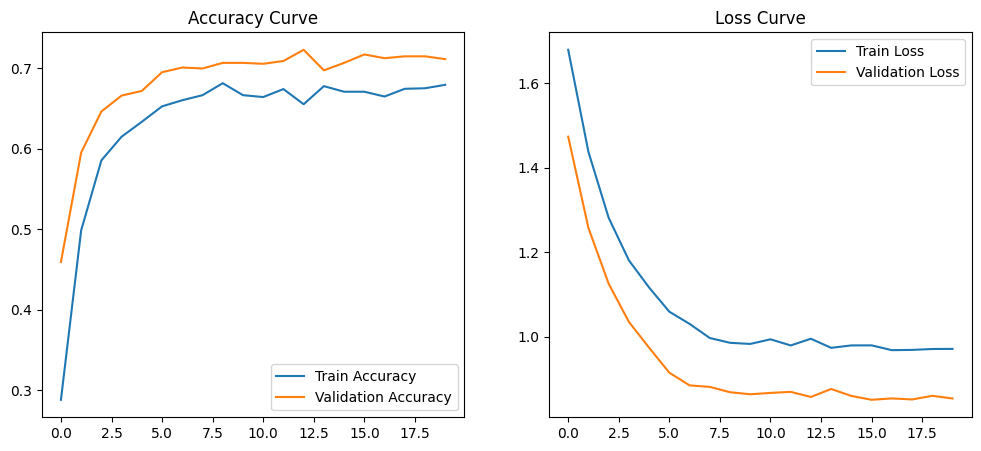

Test Accuracy: 0.7229
                   precision    recall  f1-score   support

       Dermatitis       0.64      0.82      0.72        66
Fungal_infections       0.65      0.31      0.43        54
          Healthy       0.77      0.78      0.78        69
 Hypersensitivity       0.50      0.07      0.12        29
      demodicosis       0.83      0.91      0.87       100
         ringworm       0.69      0.83      0.75       115

         accuracy                           0.72       433
        macro avg       0.68      0.62      0.61       433
     weighted avg       0.71      0.72      0.69       433



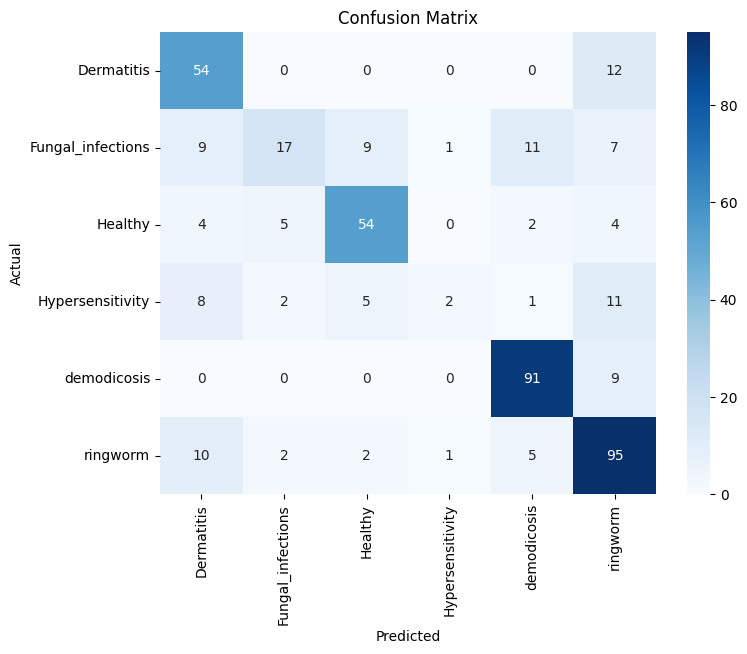

Model saved!


In [10]:
# Train the model
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=20)

"""Model Evaluation"""

def evaluate_model(model, dataloader, dataset_size):
    model.eval()
    all_preds = []
    all_labels = []
    
    running_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            running_corrects += torch.sum(preds == labels.data)
    
    accuracy = running_corrects.double() / dataset_size
    
    return all_labels, all_preds, accuracy

# Evaluate on test set
y_true, y_pred, test_accuracy = evaluate_model(model_ft, dataloaders['test'], len(image_datasets['test']))
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

"""Save and Load Model"""

# Save model
torch.save(model_ft.state_dict(), 'dog_skin_disease_model.pth')
print("Model saved!")


d:\conda_envs\catdog\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\conda_envs\catdog\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to C:\Users\alei/.cache\torch\hub\checkpoints\mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:20<00:00, 1.07MB/s]


Epoch 0/19
----------
train Loss: 1.6495 Acc: 0.3534
valid Loss: 1.4024 Acc: 0.5419

Epoch 1/19
----------
train Loss: 1.3770 Acc: 0.5635
valid Loss: 1.1351 Acc: 0.6733

Epoch 2/19
----------
train Loss: 1.2109 Acc: 0.6264
valid Loss: 0.9971 Acc: 0.7047

Epoch 3/19
----------
train Loss: 1.1142 Acc: 0.6489
valid Loss: 0.9112 Acc: 0.7116

Epoch 4/19
----------
train Loss: 1.0481 Acc: 0.6555
valid Loss: 0.8513 Acc: 0.7209

Epoch 5/19
----------
train Loss: 0.9953 Acc: 0.6747
valid Loss: 0.8037 Acc: 0.7395

Epoch 6/19
----------
train Loss: 0.9568 Acc: 0.6817
valid Loss: 0.7693 Acc: 0.7488

Epoch 7/19
----------
train Loss: 0.9300 Acc: 0.6936
valid Loss: 0.7676 Acc: 0.7512

Epoch 8/19
----------
train Loss: 0.9247 Acc: 0.6913
valid Loss: 0.7642 Acc: 0.7523

Epoch 9/19
----------
train Loss: 0.9245 Acc: 0.6830
valid Loss: 0.7617 Acc: 0.7535

Epoch 10/19
----------
train Loss: 0.9214 Acc: 0.6949
valid Loss: 0.7577 Acc: 0.7547

Epoch 11/19
----------
train Loss: 0.9182 Acc: 0.6936
valid Loss

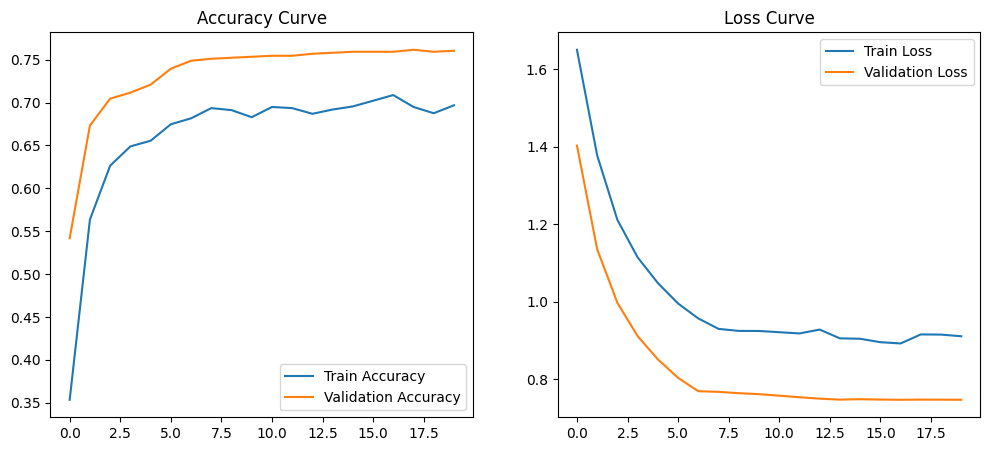

Test Accuracy: 0.7390
                   precision    recall  f1-score   support

       Dermatitis       0.65      0.83      0.73        66
Fungal_infections       0.62      0.33      0.43        54
          Healthy       0.74      0.93      0.82        69
 Hypersensitivity       0.22      0.07      0.11        29
      demodicosis       0.85      0.94      0.89       100
         ringworm       0.77      0.76      0.76       115

         accuracy                           0.74       433
        macro avg       0.64      0.64      0.62       433
     weighted avg       0.71      0.74      0.71       433



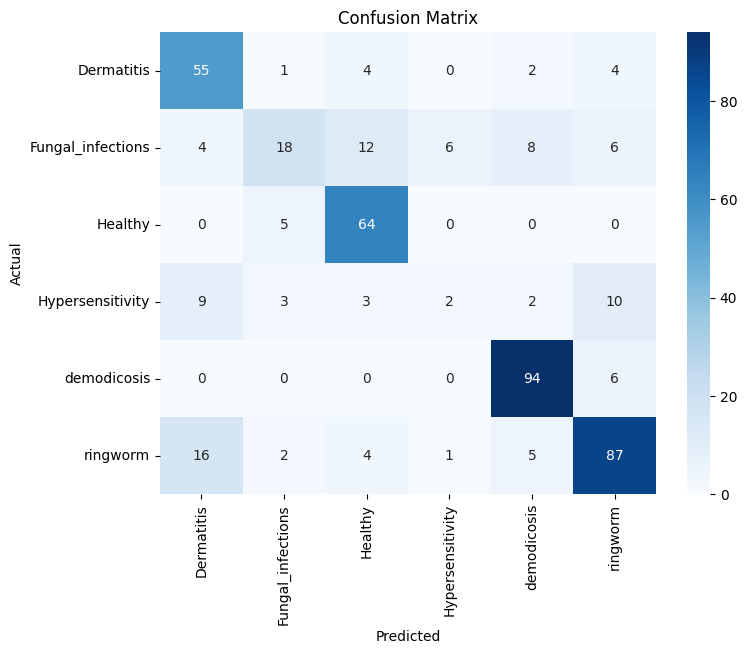

MobileNetV3模型已保存!


d:\conda_envs\catdog\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\conda_envs\catdog\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


MobileNetV3模型已成功加载!


In [11]:
# 修改为使用MobileNetV3的实现

"""Model Definition and Training with MobileNetV3"""

# 加载预训练的MobileNetV3模型（可以选择small或large版本）
# 使用large版本通常会有更好的性能，但计算成本也更高
model_ft = models.mobilenet_v3_large(pretrained=True)  # 也可以使用mobilenet_v3_small

# 冻结所有层
for param in model_ft.parameters():
    param.requires_grad = False

# MobileNetV3的分类器结构与V2不同，需要特别处理
# 获取最后一层的输入特征数
# 对于MobileNetV3，分类器是一个包含多个层的序列
in_features = model_ft.classifier[-1].in_features

# 替换分类器的最后一层以适应我们的类别数
model_ft.classifier[-1] = nn.Linear(in_features, num_classes)

# 将模型移动到设备
model_ft = model_ft.to(device)

# 定义损失函数和优化器（与之前相同）
criterion = nn.CrossEntropyLoss()
# 只优化最后一层的参数
optimizer_ft = optim.Adam(model_ft.classifier[-1].parameters(), lr=0.0001)

# 学习率调度器（与之前相同）
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# 训练模型（使用与之前相同的train_model函数）
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=20)

"""Model Evaluation"""

def evaluate_model(model, dataloader, dataset_size):
    model.eval()
    all_preds = []
    all_labels = []
    
    running_corrects = 0
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            running_corrects += torch.sum(preds == labels.data)
    
    accuracy = running_corrects.double() / dataset_size
    
    return all_labels, all_preds, accuracy

# 在测试集上评估
y_true, y_pred, test_accuracy = evaluate_model(model_ft, dataloaders['test'], len(image_datasets['test']))
print(f"Test Accuracy: {test_accuracy:.4f}")

# 分类报告
print(classification_report(y_true, y_pred, target_names=class_names))

# 混淆矩阵
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

"""Save and Load Model"""

# 保存模型
torch.save(model_ft.state_dict(), 'dog_skin_disease_mobilenetv3_model.pth')
print("MobileNetV3模型已保存!")

# 加载模型（需要先定义模型结构）
loaded_model = models.mobilenet_v3_large(pretrained=False)  # 与保存时使用相同的模型版本
in_features = loaded_model.classifier[-1].in_features
loaded_model.classifier[-1] = nn.Linear(in_features, num_classes)
loaded_model = loaded_model.to(device)
loaded_model.load_state_dict(torch.load('dog_skin_disease_mobilenetv3_model.pth'))
loaded_model.eval()
print("MobileNetV3模型已成功加载!")